# Regressão — Comparação de Modelos com Validação Cruzada

Comparamos `LinearRegression`, `Ridge`, `RandomForestRegressor` e `XGBRegressor` usando
**validação cruzada (K-Fold) somente nos dados de treino**. O conjunto de teste fica
reservado para a avaliação final, depois da otimização de hiperparâmetros.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42  # mesmo valor do 02_Baseline.ipynb, para o split de treino/teste ser idêntico


## 2. Carregar dados e separar treino/teste

In [2]:
df = pd.read_csv('../data/pib_municipios.csv')

ALVO = 'pib_per_capita'
FEATURES_NUM = ['populacao', 'participacao_agropecuaria', 'participacao_industria',
                'participacao_servicos', 'participacao_administracao_publica']
FEATURES_CAT = ['uf', 'regiao']

X = df[FEATURES_NUM + FEATURES_CAT]
y = df[ALVO]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

print('Treino:', X_train.shape, ' Teste:', X_test.shape)


Treino: (4456, 7)  Teste: (1114, 7)


## 3. Pipelines por modelo

In [3]:
preprocessador = ColumnTransformer(transformers=[
    ('num', StandardScaler(), FEATURES_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore'), FEATURES_CAT),
])

# quatro modelos com propósitos diferentes na comparação:
# - LinearRegression: piso de comparação (linear, sem regularização)
# - Ridge: mesma família, mas com regularização L2 — mostra se multicolinearidade nas dummies de UF atrapalha
# - RandomForest / XGBoost: ensembles de árvore, capturam não-linearidades que a EDA já sugeria existir
modelos = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(random_state=RANDOM_STATE),
    'RandomForest': RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
}

pipelines = {
    nome: Pipeline([('preprocessador', preprocessador), ('modelo', modelo)])
    for nome, modelo in modelos.items()
}


## 4. Validação cruzada (K-Fold, apenas no treino)

In [4]:
# shuffle=True porque os municípios estão ordenados por código IBGE (por região/UF) no CSV —
# sem embaralhar, cada fold ficaria concentrado em poucas regiões, enviesando a validação
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
metricas = ['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2']  # sklearn usa scores "neg_*" para manter a convenção de "maior é melhor"

linhas = []
resultados_cv = {}

for nome, pipe in pipelines.items():
    scores = cross_validate(pipe, X_train, y_train, cv=kfold, scoring=metricas, n_jobs=-1)
    resultados_cv[nome] = scores
    linhas.append({
        'modelo': nome,
        'RMSE_medio': -scores['test_neg_root_mean_squared_error'].mean(),
        'RMSE_std': scores['test_neg_root_mean_squared_error'].std(),  # variação entre folds = estabilidade do modelo
        'MAE_medio': -scores['test_neg_mean_absolute_error'].mean(),
        'R2_medio': scores['test_r2'].mean(),
        'R2_std': scores['test_r2'].std(),
    })

df_cv = pd.DataFrame(linhas).set_index('modelo').sort_values('RMSE_medio')
df_cv


,RMSE_medio,RMSE_std,MAE_medio,R2_medio,R2_std
modelo,,,,,
XGBoost,13124.015530,2694.429098,3971.639286,0.895732,0.035079
RandomForest,15610.094004,6937.176091,4132.263669,0.846885,0.115955
Ridge,31896.304009,6552.731048,14585.346462,0.409947,0.060906
LinearRegression,31908.149252,6559.097728,14601.369316,0.409525,0.061078


**Resultado:**

| Modelo | RMSE médio | RMSE std | MAE médio | R² médio | R² std |
|---|---:|---:|---:|---:|---:|
| XGBoost | R$ 13.124 | 2.694 | R$ 3.972 | 0,896 | 0,035 |
| RandomForest | R$ 15.610 | **6.937** | R$ 4.132 | 0,847 | 0,116 |
| Ridge | R$ 31.896 | 6.553 | R$ 14.585 | 0,410 | 0,061 |
| LinearRegression | R$ 31.908 | 6.559 | R$ 14.601 | 0,410 | 0,061 |

Dois pontos além do ranking óbvio (XGBoost > RandomForest >> Ridge ≈ LinearRegression):

- **Ridge e LinearRegression praticamente empatam.** A regularização L2 não ajudou — sinal de que
  multicolinearidade entre as dummies de UF/região não é um problema real aqui, então não vale a
  pena gastar tempo de tuning regularizando um modelo linear que já está limitado pela forma
  funcional (relação não-linear), não pela variância dos coeficientes.
- **O desvio-padrão do RandomForest entre folds (6.937) é bem maior que o do XGBoost (2.694)**,
  mesmo o RandomForest tendo RMSE médio pior. Isso quer dizer que o RandomForest não é só menos
  preciso — é menos **estável**: seu desempenho varia bastante dependendo de quais municípios caem
  em cada fold (provavelmente por causa dos outliers de mineração). **Escolha para o próximo
  notebook:** isso reforça o XGBoost como principal candidato para a otimização de hiperparâmetros
  com Optuna — não só pelo RMSE menor, mas por ser mais consistente.

## 5. Comparação visual entre modelos

C:\Users\edd-j\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\edd-j\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
C:\Users\edd-j\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\edd-j\AppData\Local\Programs\Python\Python311

C:\Users\edd-j\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


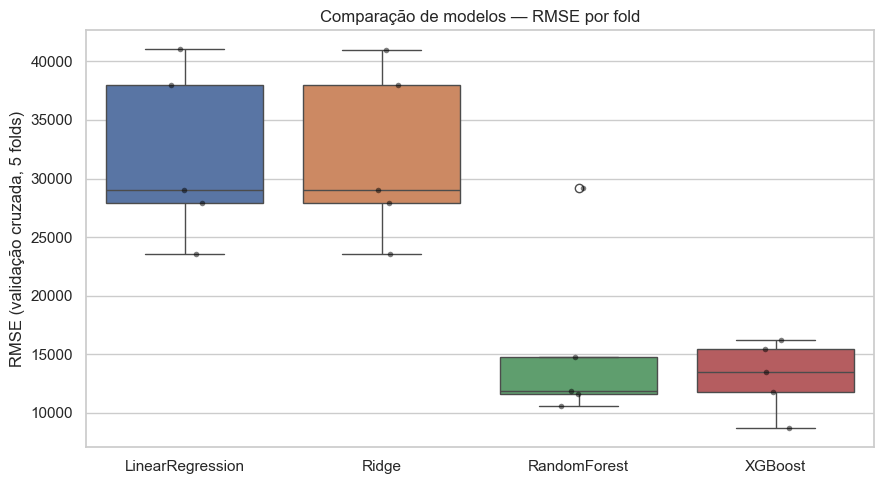

In [5]:
rmse_por_fold = pd.DataFrame({
    nome: -scores['test_neg_root_mean_squared_error'] for nome, scores in resultados_cv.items()
})

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=rmse_por_fold, ax=ax)
# stripplot sobrepõe os 5 pontos individuais de cada fold — o boxplot sozinho escondia que o
# RandomForest tem folds com erro bem discrepante entre si (visível na tabela como RMSE_std alto)
sns.stripplot(data=rmse_por_fold, ax=ax, color='black', alpha=0.5, size=4)
ax.set_ylabel('RMSE (validação cruzada, 5 folds)')
ax.set_title('Comparação de modelos — RMSE por fold')
plt.tight_layout()
plt.savefig('../reports/08_comparacao_modelos_cv.png', dpi=120)
plt.show()


## 6. Conclusão

O modelo com menor RMSE médio de validação cruzada é o candidato natural para a etapa de
otimização de hiperparâmetros no notebook `04_Otimizacao_Optuna.ipynb`. Modelos baseados em
árvore (`RandomForest`, `XGBoost`) tendem a capturar melhor relações não-lineares entre a
composição setorial da economia e o PIB per capita.

In [6]:
melhor_modelo_cv = df_cv.index[0]
print('Melhor modelo por validação cruzada:', melhor_modelo_cv)


Melhor modelo por validação cruzada: XGBoost
